# Fit bT as a Constrained Linear Combination of b0 and b1

This notebook fits the `22Na_bT.parquet` Si(Li) summed spectrum as a constrained linear combination of the `22Na_b0.parquet` and `22Na_b1.parquet` spectra:

`bT = c0*b0 + c1*b1`, with `c0 = 1 - c1`.

Default selection:
- Require the two back-to-back HPGe detectors to be in the 511 keV gate: `HPGe_1` and `HPGe_2`.
- Ignore `HPGe_3` completely.
- Fit only `100-545 keV` in the Si(Li) sum spectrum.

The notebook reports two one-parameter fits:
- A count-space fit using the selected event yields.
- A shape-only fit after normalizing each spectrum inside the fit window.

In [1]:
# Setup: imports and plotting
from __future__ import annotations

from pathlib import Path
import os

# Keep plotting cache files inside the working tree when the home directory is locked down.
_cache_root = Path.cwd() / "tmp" / "notebook_cache"
(_cache_root / "matplotlib").mkdir(parents=True, exist_ok=True)
(_cache_root / "xdg").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_cache_root / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(_cache_root / "xdg"))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Configuration

Change the gate width, binning, or fit range here. The defaults are intentionally conservative for the Si(Li) spectrum fit.

In [2]:
REPO = Path.cwd().resolve()
if REPO.name == "analysis":
    REPO = REPO.parent
elif REPO.name == "notebooks":
    REPO = REPO.parent.parent

OUTPUT_DIR = REPO / "output"
FIG_DIR = OUTPUT_DIR / "notebook_figures" / "fit_bT_linear_combination_b0_b1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "b0": OUTPUT_DIR / "22Na_b0.parquet",
    "b1": OUTPUT_DIR / "22Na_b1.parquet",
    "bT": OUTPUT_DIR / "22Na_b1.parquet",
}

HPGE_511_WINDOW = (508.0, 514.0)  # keV, applied to HPGe_1 and HPGe_2 only
USE_DOUBLE_511_GATE = True
SILI_RANGE = (0.0, 700.0)          # keV, plotted range
FIT_RANGE = (00.0, 545.0)         # keV, fit range
BIN_WIDTH = 2.0                    # keV

BINS = np.arange(SILI_RANGE[0], SILI_RANGE[1] + BIN_WIDTH, BIN_WIDTH)
CENTERS = 0.5 * (BINS[:-1] + BINS[1:])
FIT_MASK = (CENTERS >= FIT_RANGE[0]) & (CENTERS <= FIT_RANGE[1])

for label, path in FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label} input: {path}")

print(f"Repository: {REPO}")
print(f"Figures: {FIG_DIR}")
print(f"Bins: {len(CENTERS)} bins, {BIN_WIDTH:g} keV/bin")
print(f"Fit range: {FIT_RANGE[0]:g}-{FIT_RANGE[1]:g} keV")

def savefig(fig: plt.Figure, name: str) -> None:
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(path)


Repository: /Users/ronguy/Code/BpSpec/DualSiLi22Na
Figures: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1
Bins: 350 bins, 2 keV/bin
Fit range: 0-545 keV


## Load the Gated Spectra

Only the columns needed for the gate, Si(Li) sum, and event weights are read from parquet. Polars keeps the scan lazy until the final collect.

In [3]:
def gated_sili_sum_lazy(path: Path) -> pl.LazyFrame:
    lf = pl.scan_parquet(path).select(
        "E_SiLi_sum_keV",
        "E_HPGe_1_keV",
        "E_HPGe_2_keV",
        "event_weight",
    )

    selection = pl.col("E_SiLi_sum_keV").is_between(SILI_RANGE[0], SILI_RANGE[1], closed="left")
    selection &= pl.col("E_SiLi_sum_keV") > 0

    if USE_DOUBLE_511_GATE:
        lo, hi = HPGE_511_WINDOW
        selection &= pl.col("E_HPGe_1_keV").is_between(lo, hi, closed="both")
        selection &= pl.col("E_HPGe_2_keV").is_between(lo, hi, closed="both")

    return lf.filter(selection).select("E_SiLi_sum_keV", "event_weight")


def load_histogram(label: str, path: Path) -> dict:
    total = pl.scan_parquet(path).select(pl.len().alias("events_total")).collect()["events_total"][0]
    gated = gated_sili_sum_lazy(path).collect()
    energies = gated["E_SiLi_sum_keV"].to_numpy()
    weights = gated["event_weight"].cast(pl.Float64).to_numpy()
    hist, _ = np.histogram(energies, bins=BINS, weights=weights)
    hist_unweighted, _ = np.histogram(energies, bins=BINS)
    return {
        "label": label,
        "path": path,
        "events_total": int(total),
        "events_gated": int(len(gated)),
        "weight_gated": float(weights.sum()),
        "hist": hist.astype(float),
        "hist_unweighted": hist_unweighted.astype(float),
    }

spectra = {label: load_histogram(label, path) for label, path in FILES.items()}
summary = pl.DataFrame([
    {
        "spectrum": label,
        "file": str(item["path"]),
        "events_total": item["events_total"],
        "events_gated": item["events_gated"],
        "weighted_gated": item["weight_gated"],
        "gate_fraction": item["events_gated"] / item["events_total"],
    }
    for label, item in spectra.items()
])
summary

spectrum,file,events_total,events_gated,weighted_gated,gate_fraction
str,str,i64,i64,f64,f64
"""b0""","""/Users/ronguy/Code/BpSpec/Dual…",100000000,839410,839410.0,0.0083941
"""b1""","""/Users/ronguy/Code/BpSpec/Dual…",100000000,841710,841710.0,0.0084171
"""bT""","""/Users/ronguy/Code/BpSpec/Dual…",100000000,841710,841710.0,0.0084171


## Constrained Linear Combination Fits

Both fits use one free parameter, `c1`, with `c0 = 1 - c1`. The count-space fit preserves the absolute selected yields. The shape-only fit normalizes each spectrum inside the fit window before fitting the `b1` fraction.

In [4]:
def fit_constrained_mixture(y: np.ndarray, a: np.ndarray, b: np.ndarray, sigma: np.ndarray) -> dict:
    """Fit y = (1 - c1) * a + c1 * b with weighted least squares."""
    good = np.isfinite(y) & np.isfinite(a) & np.isfinite(b) & np.isfinite(sigma) & (sigma > 0)
    y_fit = y[good]
    a_fit = a[good]
    b_fit = b[good]
    sigma_fit = sigma[good]
    delta = b_fit - a_fit
    resid0 = y_fit - a_fit
    w = 1.0 / sigma_fit**2
    denom = float(np.sum(w * delta**2))
    if denom <= 0:
        raise ValueError("The b0 and b1 templates are indistinguishable in the fit window")
    c1 = float(np.sum(w * delta * resid0) / denom)
    c1_err = float(np.sqrt(1.0 / denom))
    c0 = 1.0 - c1
    model_fit = a_fit + c1 * delta
    residual = y_fit - model_fit
    chi2 = float(np.sum((residual / sigma_fit) ** 2))
    dof = max(1, y_fit.size - 1)
    return {
        "c0": c0,
        "c1": c1,
        "c0_err": c1_err,
        "c1_err": c1_err,
        "cov": np.array([[c1_err**2, -c1_err**2], [-c1_err**2, c1_err**2]]),
        "chi2": chi2,
        "dof": dof,
        "chi2_ndf": chi2 / dof,
        "mask": good,
    }

h0 = spectra["b0"]["hist"]
h1 = spectra["b1"]["hist"]
hT = spectra["bT"]["hist"]

# Count-space constrained WLS. Include target counting uncertainty; this is a compact approximation.
y_count = hT[FIT_MASK]
b0_count = h0[FIT_MASK]
b1_count = h1[FIT_MASK]
sigma_count = np.sqrt(np.maximum(hT[FIT_MASK], 1.0))
count_fit = fit_constrained_mixture(y_count, b0_count, b1_count, sigma_count)
count_model = np.full_like(hT, np.nan, dtype=float)
count_model[FIT_MASK] = h0[FIT_MASK] + count_fit["c1"] * (h1[FIT_MASK] - h0[FIT_MASK])

# Shape-only constrained fit. Normalize all spectra inside the fit range.
def normalize_in_fit_window(h: np.ndarray) -> tuple[np.ndarray, float]:
    total = float(h[FIT_MASK].sum())
    if total <= 0:
        raise ValueError("Cannot normalize an empty fit-window histogram")
    return h / total, total

p0, n0_fit = normalize_in_fit_window(h0)
p1, n1_fit = normalize_in_fit_window(h1)
pT, nT_fit = normalize_in_fit_window(hT)

# For normalized target counts, sigma(p) ~= sqrt(N_i) / N_total.
sigma_shape = np.sqrt(np.maximum(hT[FIT_MASK], 1.0)) / nT_fit
shape_fit = fit_constrained_mixture(pT[FIT_MASK], p0[FIT_MASK], p1[FIT_MASK], sigma_shape)
f_b1 = shape_fit["c1"]
f_b1_err = shape_fit["c1_err"]
shape_model = (1.0 - f_b1) * p0 + f_b1 * p1
shape_resid = pT[FIT_MASK] - shape_model[FIT_MASK]
shape_chi2 = shape_fit["chi2"]
shape_dof = shape_fit["dof"]

fit_summary = pl.DataFrame([
    {
        "fit": "count_space_constrained",
        "c0": float(count_fit["c0"]),
        "c0_err": float(count_fit["c0_err"]),
        "c1": float(count_fit["c1"]),
        "c1_err": float(count_fit["c1_err"]),
        "chi2": count_fit["chi2"],
        "dof": count_fit["dof"],
        "chi2_ndf": count_fit["chi2_ndf"],
    },
    {
        "fit": "shape_only_constrained",
        "c0": float(shape_fit["c0"]),
        "c0_err": float(shape_fit["c0_err"]),
        "c1": float(shape_fit["c1"]),
        "c1_err": float(shape_fit["c1_err"]),
        "chi2": shape_chi2,
        "dof": shape_dof,
        "chi2_ndf": shape_chi2 / shape_dof,
    },
])
fit_summary

fit,c0,c0_err,c1,c1_err,chi2,dof,chi2_ndf
str,f64,f64,f64,f64,f64,i64,f64
"""count_space_constrained""",0.0,0.016686,1.0,0.016686,0.0,272,0.0
"""shape_only_constrained""",1.1102e-16,0.016655,1.0,0.016655,2.1179e-31,272,7.7866e-34


## Convert Template Coefficient to Physical Fierz b

The fitted coefficient `c1` is the coordinate between the **normalized** `b=0` and `b=1` templates. It is not equal to the physical Fierz `b` after spectrum normalization.

For spectra of the form `S_b(E) ∝ S_0(E) * (1 + b*g(E))`, normalization gives:

`c = b * (1 + G) / (1 + b*G)`

so:

`b = c / (1 + G*(1 - c))`.

The calibration below estimates `G` from the raw closure spectra. It should map `22Na_25.raw` back to physical `b = 0.25`.

In [5]:
def read_raw_spectrum(path: Path) -> tuple[np.ndarray, np.ndarray]:
    energy = []
    rate = []
    with path.open() as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            energy.append(float(parts[1]))
            rate.append(float(parts[2]))
    return np.asarray(energy), np.asarray(rate)


def normalized_template_coordinate(target: np.ndarray, b0: np.ndarray, b1: np.ndarray, mask: np.ndarray) -> float:
    def norm(y: np.ndarray) -> np.ndarray:
        return y / np.sum(y[mask])
    pT = norm(target)
    p0 = norm(b0)
    p1 = norm(b1)
    delta = p1[mask] - p0[mask]
    resid = pT[mask] - p0[mask]
    return float(np.sum(delta * resid) / np.sum(delta * delta))


def infer_G_from_closure(physical_b: float, template_c: float) -> float:
    return float((physical_b - template_c) / (physical_b * (template_c - 1.0)))


def physical_b_from_template_c(template_c: float, G: float) -> float:
    return float(template_c / (1.0 + G * (1.0 - template_c)))


def physical_b_error_from_template_c(template_c: float, template_c_err: float, G: float) -> float:
    denom = 1.0 + G * (1.0 - template_c)
    derivative = (1.0 + G) / (denom * denom)
    return float(abs(derivative) * template_c_err)

raw_fit_mask = fit_mask_for_window(FIT_RANGE) if "fit_mask_for_window" in globals() else FIT_MASK
raw_energy, raw_b0 = read_raw_spectrum(REPO / "22Na_0.raw")
_, raw_b1 = read_raw_spectrum(REPO / "22Na_1.raw")
raw_mask = (raw_energy >= FIT_RANGE[0]) & (raw_energy <= FIT_RANGE[1])

closure_inputs = []
for physical_b, raw_name in [(0.05, "22Na_05.raw"), (0.25, "22Na_25.raw")]:
    raw_path = REPO / raw_name
    if raw_path.exists():
        _, raw_target = read_raw_spectrum(raw_path)
        template_c = normalized_template_coordinate(raw_target, raw_b0, raw_b1, raw_mask)
        closure_inputs.append({
            "raw_file": raw_name,
            "physical_b": physical_b,
            "template_c": template_c,
            "inferred_G": infer_G_from_closure(physical_b, template_c),
            "roundtrip_physical_b": physical_b_from_template_c(template_c, infer_G_from_closure(physical_b, template_c)),
        })

fierz_G = float(np.mean([row["inferred_G"] for row in closure_inputs]))
fierz_mapping_table = pl.DataFrame(closure_inputs)
print(f"Fierz normalization mapping G = {fierz_G:.6f}")
fierz_mapping_table

Fierz normalization mapping G = 0.719771


raw_file,physical_b,template_c,inferred_G,roundtrip_physical_b
str,f64,f64,f64,f64
"""22Na_05.raw""",0.05,0.083002,0.719774,0.05
"""22Na_25.raw""",0.25,0.364376,0.719768,0.25


## Physical Fierz b from the Fit

This table applies the normalization mapping to the one-parameter template-coordinate fits above.

In [6]:
physical_fit_summary = fit_summary.with_columns(
    physical_b=pl.col("c1").map_elements(lambda x: physical_b_from_template_c(float(x), fierz_G), return_dtype=pl.Float64),
    physical_b_err=pl.struct(["c1", "c1_err"]).map_elements(
        lambda s: physical_b_error_from_template_c(float(s["c1"]), float(s["c1_err"]), fierz_G),
        return_dtype=pl.Float64,
    ),
)
physical_fit_summary

fit,c0,c0_err,c1,c1_err,chi2,dof,chi2_ndf,physical_b,physical_b_err
str,f64,f64,f64,f64,f64,i64,f64,f64,f64
"""count_space_constrained""",0.0,0.016686,1.0,0.016686,0.0,272,0.0,1.0,0.028696
"""shape_only_constrained""",1.1102e-16,0.016655,1.0,0.016655,2.1179e-31,272,7.7866e-34,1.0,0.028642


## Coefficient Results and One-Dimensional Profile

Because `c0 = 1 - c1`, there is no independent two-dimensional contour. The next cell shows the constrained coefficient table and plots the one-dimensional `Δχ²` profile for `c1`; the corresponding `c0` value is shown on the upper x-axis.

Constraint: c0 + c1 = 1
Best-fit c1 = 1.000000 +/- 0.016686
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1/count_space_c1_profile.png


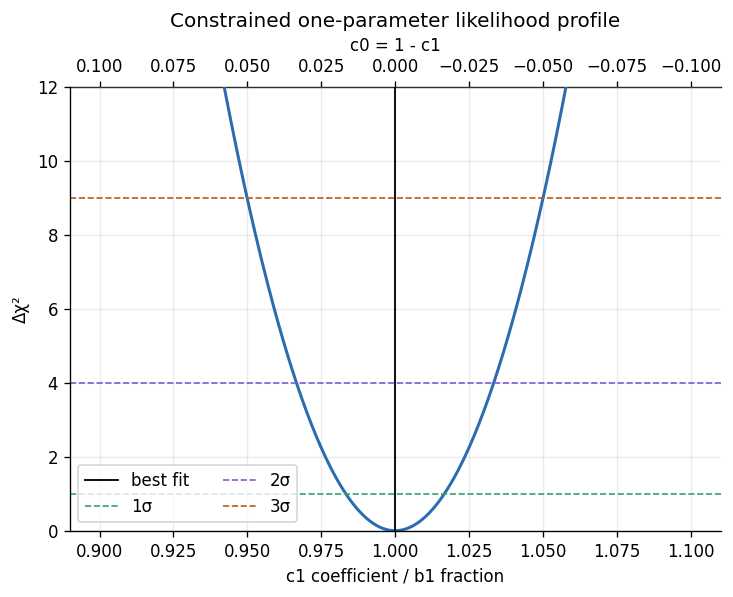

In [7]:
# Explicit constrained c0/c1 fit results and count-space chi-square profile
c1_hat = count_fit["c1"]
c1_err = count_fit["c1_err"]
c0_hat = count_fit["c0"]

coefficient_table = pl.DataFrame({
    "coefficient": ["c0 = 1 - c1", "c1"],
    "value": [c0_hat, c1_hat],
    "uncertainty_1sigma": [c1_err, c1_err],
})
print("Constraint: c0 + c1 = 1")
print(f"Best-fit c1 = {c1_hat:.6f} +/- {c1_err:.6f}")
coefficient_table

# Profile chi-square as a function of the single free parameter c1.
profile_half_width = max(6.0 * c1_err, 0.10)
c1_profile = np.linspace(c1_hat - profile_half_width, c1_hat + profile_half_width, 500)
model_profile = b0_count[None, :] + c1_profile[:, None] * (b1_count - b0_count)[None, :]
chi2_profile = np.sum(((y_count[None, :] - model_profile) / sigma_count[None, :]) ** 2, axis=1)
delta_chi2_profile = chi2_profile - np.nanmin(chi2_profile)

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(c1_profile, delta_chi2_profile, color="#2b6cb0", linewidth=1.8)
ax.axvline(c1_hat, color="black", linewidth=1.1, label="best fit")
for level, label, color in [(1.0, "1σ", "#38a169"), (4.0, "2σ", "#805ad5"), (9.0, "3σ", "#c05621")]:
    ax.axhline(level, color=color, linestyle="--", linewidth=1.0, label=label)
ax.set_xlabel("c1 coefficient / b1 fraction")
ax.set_ylabel("Δχ²")
ax.set_title("Constrained one-parameter likelihood profile")
ax.set_ylim(0, min(12, np.nanmax(delta_chi2_profile)))
ax.legend(ncol=2)

def c1_to_c0(x):
    return 1.0 - x

def c0_to_c1(x):
    return 1.0 - x

secax = ax.secondary_xaxis("top", functions=(c1_to_c0, c0_to_c1))
secax.set_xlabel("c0 = 1 - c1")
savefig(fig, "count_space_c1_profile.png")
plt.show()

## Bayesian One-Parameter Fit with PyMC

This cell fits the same binned count-space model with PyMC using one free coefficient, `c1`, and the deterministic relation `c0 = 1 - c1`. The prior below is broad and unconstrained so the posterior interval is not artificially clipped at zero. If you want a strictly physical mixture, replace it with `pm.Uniform("c1", lower=0, upper=1)`.

In [8]:
# Bayesian constrained fit for c1 using PyMC
import arviz as az
import pymc as pm

with pm.Model() as constrained_combo_model:
    c1 = pm.Normal("c1", mu=0.0, sigma=1.0)
    c0 = pm.Deterministic("c0", 1.0 - c1)
    mu = (1.0 - c1) * b0_count + c1 * b1_count
    pm.Normal("observed_counts", mu=mu, sigma=sigma_count, observed=y_count)

    idata = pm.sample(
        draws=1500,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=20240622,
        progressbar=False,
    )

posterior_summary = az.summary(idata, var_names=["c0", "c1"], hdi_prob=0.95)
posterior_summary

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [c1]


Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 0 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c0,0.0,0.017,-0.032,0.033,0.0,0.0,2121.0,2184.0,1.0
c1,1.0,0.017,0.967,1.032,0.0,0.0,2121.0,2184.0,1.0


/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1/pymc_constrained_c1_posterior.png


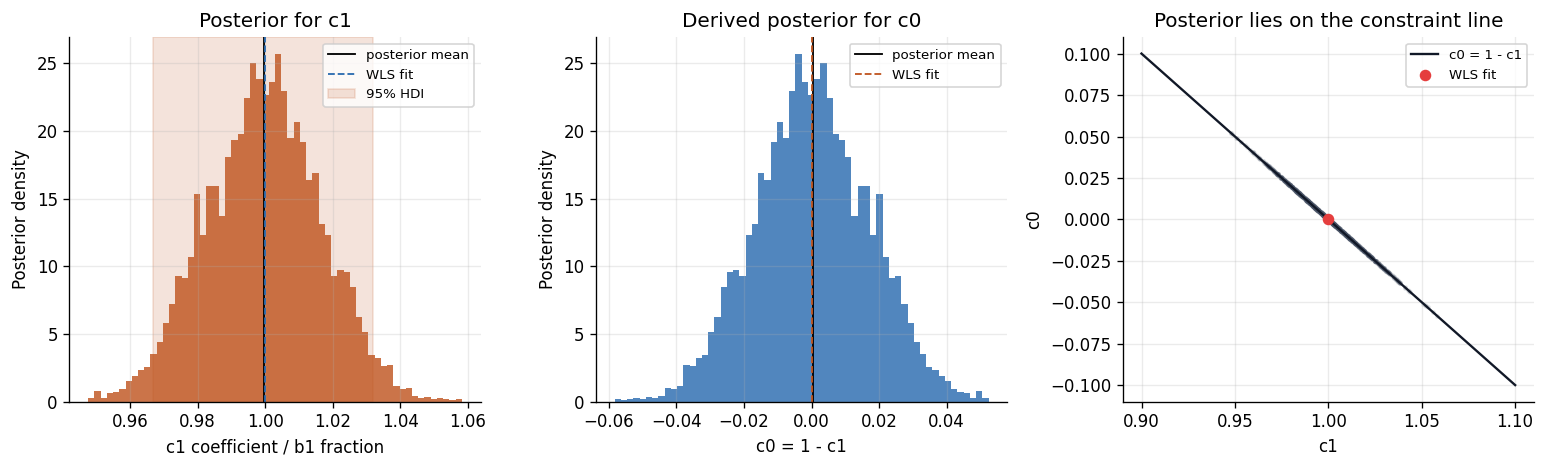

Posterior c1: mean=0.999661, median=0.999914, 95% HDI=[0.9668313 1.0320264]
Posterior c0 = 1 - c1: mean=0.000339, median=0.000086, 95% HDI=[-0.0320264  0.0331687]


In [9]:
# Posterior plots for the constrained one-parameter model
posterior = idata.posterior
c1_samples = posterior["c1"].values.reshape(-1)
c0_samples = posterior["c0"].values.reshape(-1)
c1_hdi = az.hdi(c1_samples, hdi_prob=0.95)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(c1_samples, bins=60, color="#c05621", alpha=0.82, density=True)
axes[0].axvline(np.mean(c1_samples), color="black", linewidth=1.1, label="posterior mean")
axes[0].axvline(c1_hat, color="#2b6cb0", linestyle="--", linewidth=1.1, label="WLS fit")
axes[0].axvspan(c1_hdi[0], c1_hdi[1], color="#c05621", alpha=0.16, label="95% HDI")
axes[0].set_xlabel("c1 coefficient / b1 fraction")
axes[0].set_ylabel("Posterior density")
axes[0].set_title("Posterior for c1")
axes[0].legend(fontsize=8)

axes[1].hist(c0_samples, bins=60, color="#2b6cb0", alpha=0.82, density=True)
axes[1].axvline(np.mean(c0_samples), color="black", linewidth=1.1, label="posterior mean")
axes[1].axvline(c0_hat, color="#c05621", linestyle="--", linewidth=1.1, label="WLS fit")
axes[1].set_xlabel("c0 = 1 - c1")
axes[1].set_ylabel("Posterior density")
axes[1].set_title("Derived posterior for c0")
axes[1].legend(fontsize=8)

axes[2].scatter(c1_samples[::4], c0_samples[::4], s=4, alpha=0.12, color="#4a5568")
axes[2].plot(c1_profile, 1.0 - c1_profile, color="#111827", linewidth=1.4, label="c0 = 1 - c1")
axes[2].scatter([c1_hat], [c0_hat], color="#e53e3e", s=35, label="WLS fit", zorder=3)
axes[2].set_xlabel("c1")
axes[2].set_ylabel("c0")
axes[2].set_title("Posterior lies on the constraint line")
axes[2].legend(fontsize=8)
fig.tight_layout()
savefig(fig, "pymc_constrained_c1_posterior.png")
plt.show()

print(
    "Posterior c1: "
    f"mean={np.mean(c1_samples):.6f}, "
    f"median={np.median(c1_samples):.6f}, "
    f"95% HDI={c1_hdi}"
)
print(
    "Posterior c0 = 1 - c1: "
    f"mean={np.mean(c0_samples):.6f}, "
    f"median={np.median(c0_samples):.6f}, "
    f"95% HDI={az.hdi(c0_samples, hdi_prob=0.95)}"
)

## Spectra and Fit Residuals

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1/input_sili_sum_spectra.png


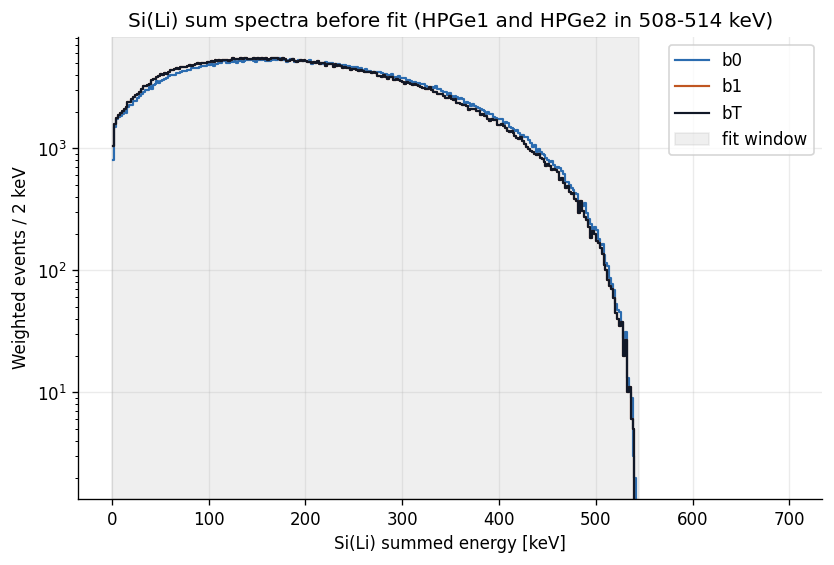

In [10]:
colors = {"b0": "#2b6cb0", "b1": "#c05621", "bT": "#111827"}

fig, ax = plt.subplots(figsize=(8, 5))
for label in ["b0", "b1", "bT"]:
    ax.step(CENTERS, spectra[label]["hist"], where="mid", label=label, color=colors[label], linewidth=1.3)
ax.axvspan(FIT_RANGE[0], FIT_RANGE[1], color="grey", alpha=0.12, label="fit window")
if USE_DOUBLE_511_GATE:
    gate_text = f"HPGe1 and HPGe2 in {HPGE_511_WINDOW[0]:.0f}-{HPGE_511_WINDOW[1]:.0f} keV"
else:
    gate_text = "no HPGe gate"
ax.set_title(f"Si(Li) sum spectra before fit ({gate_text})")
ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel(f"Weighted events / {BIN_WIDTH:g} keV")
ax.set_yscale("log")
ax.legend()
savefig(fig, "input_sili_sum_spectra.png")
plt.show()

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1/count_space_linear_fit.png


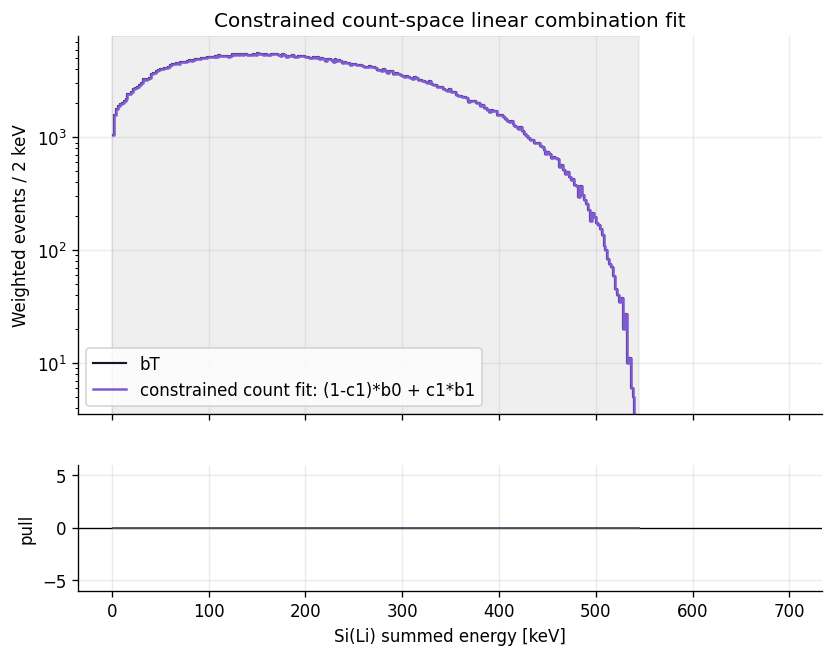

In [11]:
fig, (ax, rax) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=[3, 1])
ax.step(CENTERS, hT, where="mid", color=colors["bT"], label="bT", linewidth=1.3)
ax.step(CENTERS[FIT_MASK], count_model[FIT_MASK], where="mid", color="#805ad5", label="constrained count fit: (1-c1)*b0 + c1*b1", linewidth=1.5)
ax.axvspan(FIT_RANGE[0], FIT_RANGE[1], color="grey", alpha=0.12)
ax.set_yscale("log")
ax.set_ylabel(f"Weighted events / {BIN_WIDTH:g} keV")
ax.set_title("Constrained count-space linear combination fit")
ax.legend()

resid = np.full_like(hT, np.nan, dtype=float)
sigma_full = np.sqrt(np.maximum(hT, 1.0))
resid[FIT_MASK] = (hT[FIT_MASK] - count_model[FIT_MASK]) / sigma_full[FIT_MASK]
rax.axhline(0, color="black", linewidth=0.8)
rax.step(CENTERS[FIT_MASK], resid[FIT_MASK], where="mid", color="#4a5568", linewidth=1.1)
rax.set_xlabel("Si(Li) summed energy [keV]")
rax.set_ylabel("pull")
rax.set_ylim(-6, 6)
savefig(fig, "count_space_linear_fit.png")
plt.show()

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1/shape_only_linear_fit.png


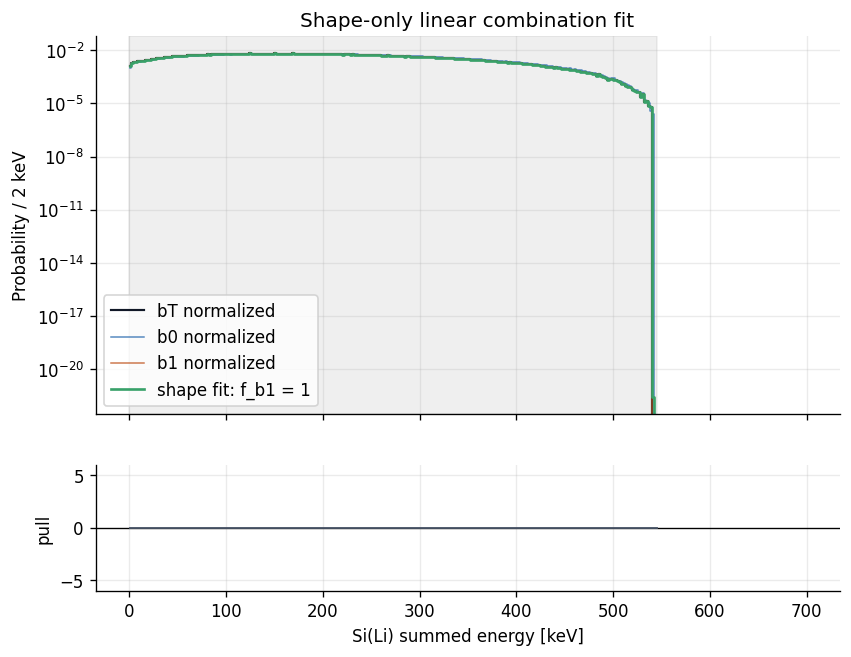

In [12]:
fig, (ax, rax) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=[3, 1])
ax.step(CENTERS, pT, where="mid", color=colors["bT"], label="bT normalized", linewidth=1.3)
ax.step(CENTERS, p0, where="mid", color=colors["b0"], label="b0 normalized", linewidth=0.9, alpha=0.8)
ax.step(CENTERS, p1, where="mid", color=colors["b1"], label="b1 normalized", linewidth=0.9, alpha=0.8)
ax.step(CENTERS[FIT_MASK], shape_model[FIT_MASK], where="mid", color="#38a169", label=f"shape fit: f_b1 = {f_b1:.4g}", linewidth=1.6)
ax.axvspan(FIT_RANGE[0], FIT_RANGE[1], color="grey", alpha=0.12)
ax.set_yscale("log")
ax.set_ylabel(f"Probability / {BIN_WIDTH:g} keV")
ax.set_title("Shape-only linear combination fit")
ax.legend()

shape_pull = (pT[FIT_MASK] - shape_model[FIT_MASK]) / sigma_shape
rax.axhline(0, color="black", linewidth=0.8)
rax.step(CENTERS[FIT_MASK], shape_pull, where="mid", color="#4a5568", linewidth=1.1)
rax.set_xlabel("Si(Li) summed energy [keV]")
rax.set_ylabel("pull")
rax.set_ylim(-6, 6)
savefig(fig, "shape_only_linear_fit.png")
plt.show()

## Export Binned Results

The CSV output is small and contains the fit model values bin-by-bin for quick checks outside the notebook.

In [13]:
result_table = pl.DataFrame({
    "energy_center_keV": CENTERS,
    "in_fit_window": FIT_MASK,
    "b0_counts": h0,
    "b1_counts": h1,
    "bT_counts": hT,
    "constrained_count_fit_model": np.where(FIT_MASK, count_model, np.nan),
    "b0_shape": p0,
    "b1_shape": p1,
    "bT_shape": pT,
    "constrained_shape_fit_model": shape_model,
})

result_path = FIG_DIR / "bT_constrained_linear_combination_binned_fit.csv"
summary_path = FIG_DIR / "bT_constrained_linear_combination_fit_summary.csv"
result_table.write_csv(result_path)
physical_fit_summary.write_csv(summary_path)
print(result_path)
print(summary_path)

/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1/bT_constrained_linear_combination_binned_fit.csv
/Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures/fit_bT_linear_combination_b0_b1/bT_constrained_linear_combination_fit_summary.csv


## Notes

- The fit is intentionally one-dimensional: `c0` and `c1` are not independent because `c0 = 1 - c1`.
- The shape-only `c1` is the cleanest answer if `b0`, `b1`, and `bT` were generated with the same number of events and you want the spectral mixture rather than absolute yield matching.
- The Bayesian cell uses an unconstrained broad normal prior for `c1`; switch to a `Uniform(0, 1)` prior only if you want to enforce a strictly physical interpolation.
- `HPGe_3` is not used in this notebook's default gate.
- Template-coordinate `c1` is not the physical Fierz `b`; use the conversion table above for physical `b`.
